In [ ]:
# Dependencies for processing the raw results and generating the charts.
# (No cloud SDK needed — raw files are read from the local `raw/` folder.)
!pip install pandas matplotlib numpy

In [ ]:
from __future__ import annotations
import os
import json
from pathlib import Path
from typing import List
import pandas as pd
import re

# --- Config ---
# Raw experimental results live in the repository's `raw/` folder (one JSON per run,
# named after the run timestamp). Processed CSVs are written to the `dataset/` folder.
# Resolve the folders whether the notebook is run from `figures/` or the repo root.
def _resolve_dir(name: str) -> Path:
    for cand in (Path(name), Path("..") / name):
        if cand.is_dir():
            return cand
    # default to the sibling layout (notebook lives in figures/)
    return Path("..") / name

RAW_DIR = _resolve_dir("raw")          # source: raw JSON files
DATASET_DIR = _resolve_dir("dataset")  # destination: processed CSVs
DATASET_DIR.mkdir(parents=True, exist_ok=True)

experiments = [
    {"kind": "baseline", "file": "2025-09-01-10-36-47/results.json"}, # baseline 25,50,75 300 400 500 user
    {"kind": "retry_checkout", "file": "2025-08-31-16-46-24/results.json"}, # checkout retry 25. 300 400 500 user fault on "paymentservice" "checkoutservice"
    {"kind": "retry_checkout", "file": "2025-08-31-11-35-58/results.json"}, # checkout retry 50. 300 400 500 user fault on "paymentservice" "checkoutservice"
    {"kind": "retry_checkout", "file": "2025-08-31-20-31-55/results.json"}, # checkout retry 75. 300 400 500 user fault on "paymentservice" "checkoutservice"

    {"kind": "retry_frontend", "file": "2025-09-01-14-34-40/results.json"}, # frontend retry 25. 300 400 500 user fault "paymentservice" "checkoutservice"
    {"kind": "retry_frontend", "file": "2025-09-01-20-10-48/results.json"}, # frontend retry 50. 300 400 500 user fault "paymentservice" "checkoutservice"
    {"kind": "retry_frontend", "file": "2025-09-01-22-13-50/results.json"}, # frontend retry 75. 300 400 500 user fault "paymentservice" "checkoutservice"

    {"kind": "retry_all", "file": "2025-10-07-23-26-04/results.json"}, # retry nos dois conectores - 25% falha e 500 users
    {"kind": "retry_all", "file": "2025-10-10-13-15-47/results.json"}, # retry nos dois conectores - 50% falha e 500 users
    {"kind": "retry_all", "file": "2025-10-12-14-53-55/results.json"}, # retry nos dois conectores - 75% falha e 500 users

    {"kind": "retry_all", "file": "2025-10-14-23-17-24/results.json"}, # retry nos dois conectores - 25% falha e 300 users
    {"kind": "retry_all", "file": "2025-10-23-01-16-08/results.json"}, # retry nos dois conectores - 50% falha e 300 users
    {"kind": "retry_all", "file": "2025-10-20-09-50-25/results.json"}, # retry nos dois conectores - 75% falha e 300 users
]

# --- Utilitários ---

def safe_colname(name: str) -> str:
    name = (name or "").lower().replace("-", "_")
    return re.sub(r"\W+", "_", name).strip("_")

def parse_scenario_type(scenario: str) -> str:
    s = (scenario or "").lower()
    return "retry" if "retry" in s or "retry" in s else "baseline"

def parse_grpc_param(val) -> float:
    """Converte '0.5s' -> 0.5 | 'NaN' -> 0.0 | números -> float."""
    if val in (None, "", "NaN"):
        return 0.0
    s = str(val).strip().lower()
    if s.endswith("s"):
        s = s[:-1]
    try:
        return float(s)
    except ValueError:
        return 0.0

def resolve_raw_files(keys: List[str], raw_dir: Path) -> List[Path]:
    """Resolve raw JSON paths from the local `raw/` folder.

    The experiment `file` entries use the original S3 layout (`<timestamp>/results.json`).
    In the local `raw/` folder each run is stored as a single `<timestamp>.json` file.
    """
    local_paths: List[Path] = []
    for object_key in keys:
        run_id = Path(object_key).parent.name  # e.g. "2025-09-01-10-36-47"
        local_path = raw_dir / f"{run_id}.json"
        if local_path.exists():
            local_paths.append(local_path)
        else:
            print(f"[WARN] Arquivo raw não encontrado: {local_path}")
    return local_paths

def extract_connectors_to_columns(df: pd.DataFrame) -> pd.DataFrame:
    def connectors_to_series(connectors):
        if not isinstance(connectors, (list, tuple)):
            return pd.Series(dtype=object)

        out = {}
        for item in connectors:
            service_name = safe_colname(item.get("name", ""))
            if not service_name:
                continue

            out[f"{service_name}_GRPC_BACKOFF_MULTIPLIER"] = parse_grpc_param(
                item.get("source_env_GRPC_BACKOFF_MULTIPLIER")
            )
            out[f"{service_name}_GRPC_INITIAL_BACKOFF"] = parse_grpc_param(
                item.get("source_env_GRPC_INITIAL_BACKOFF")
            )
            out[f"{service_name}_GRPC_MAX_ATTEMPTS"] = parse_grpc_param(
                item.get("source_env_GRPC_MAX_ATTEMPTS")
            )
            out[f"{service_name}_GRPC_MAX_BACKOFF"] = parse_grpc_param(
                item.get("source_env_GRPC_MAX_BACKOFF")
            )

        return pd.Series(out, dtype="float64")

    expanded = df["connectors"].apply(connectors_to_series)
    return pd.concat([df.drop(columns=["connectors"], errors="ignore"), expanded], axis=1)

def minmax_by_group(df: pd.DataFrame, col: str, group_cols: List[str], out_col: str | None = None) -> pd.DataFrame:
    """Normaliza col em [0,1] por grupos; protege contra variança zero."""
    out_col = out_col or f"normalized_{col}"
    g = df.groupby(group_cols)[col]
    mins = g.transform("min")
    maxs = g.transform("max")
    denom = (maxs - mins).replace(0, 1)  # evita divisão por zero
    df[out_col] = (df[col] - mins) / denom
    return df

def extract_file_data(local_path: Path, scenario_group: str = "") -> pd.DataFrame:
    with local_path.open("r") as f:
        data = json.load(f)

    df_results = pd.DataFrame(data.get("results", []))


    # Tipagens básicas se existirem
    for c in ["checkout_success_rate", "checkout_http_req_duration", "iteration_duration_p(95)"]:
        if c in df_results.columns:
            df_results[c] = pd.to_numeric(df_results[c], errors="coerce")

    # cenário
    if scenario_group:
        df_results["scenario_group"] = scenario_group

    if "scenario" in df_results.columns:
        df_results["scenario_type"] = df_results["scenario"].apply(parse_scenario_type)
    else:
        df_results["scenario_type"] = "baseline"

    # expandir conectores
    if "connectors" in df_results.columns:
        df_results = extract_connectors_to_columns(df_results)

    # normalizações por (fault, workload), se colunas existirem
    if {"fault_percentage", "workload_users"} <= set(df_results.columns):
        for c in ["checkout_http_req_duration", "iteration_duration_p(95)"]:
            if c in df_results.columns:
                df_results = minmax_by_group(
                    df_results, col=c,
                    group_cols=["fault_percentage", "workload_users"],
                    out_col=f"normalized_{c}"
                )

    # métricas derivadas
    if "checkout_success_rate" in df_results.columns:
        df_results["checkout_error_rate"] = 1 - df_results["checkout_success_rate"]

    return df_results.fillna(0)

# --- Execução ---

local_files = resolve_raw_files([exp.get('file') for exp in experiments], RAW_DIR)

dfs = []
for lp in local_files:
  kind = ''
  for exp in experiments:
    if exp.get('file').split('/')[0] == lp.name.split('.')[0]:
       kind = exp.get('kind')
       break
  dfs.append(extract_file_data(lp, kind))

if not dfs:
    raise SystemExit("Nenhum arquivo processado com sucesso.")

df = pd.concat(dfs, ignore_index=True)

# partições
retry_df = df[df["scenario_type"] != "baseline"].copy()
baseline_df = df[df["scenario_type"] == "baseline"].copy()

desired_columns = [
    'scenario','scenario_type', 'scenario_group', 'fault_percentage','workload_users',
    'checkout_error','checkout_success','checkout_success_rate','checkout_http_req_duration',
    'iteration_duration_p(95)', 'normalized_iteration_duration_p(95)'
]
grpc_regex = r'(^|_)GRPC_'
def keep_desired_and_grpc(df):
    return pd.concat(
        [df[[c for c in desired_columns if c in df.columns]],
         df.filter(regex=grpc_regex)],
        axis=1
    )


retry_df = keep_desired_and_grpc(retry_df).drop_duplicates(subset=["scenario"])
baseline_df = keep_desired_and_grpc(baseline_df).drop_duplicates(subset=["scenario"])

retry_df = retry_df[retry_df["workload_users"] != 400]
baseline_df = baseline_df[baseline_df["workload_users"] != 400]

# retry_df.head()

baseline_df.head(10)

retry_df.to_csv(DATASET_DIR / 'retry.csv', index=False)
baseline_df.to_csv(DATASET_DIR / 'baseline.csv', index=False)


                  ploting 36 points for retry_checkout
                  workload 300 and
                  fault 25
                

                  ploting 36 points for retry_checkout
                  workload 300 and
                  fault 50
                

                  ploting 36 points for retry_checkout
                  workload 300 and
                  fault 75
                

                  ploting 35 points for retry_checkout
                  workload 500 and
                  fault 25
                

                  ploting 36 points for retry_checkout
                  workload 500 and
                  fault 50
                

                  ploting 36 points for retry_checkout
                  workload 500 and
                  fault 75
                


/tmp/ipython-input-3078822110.py:161: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


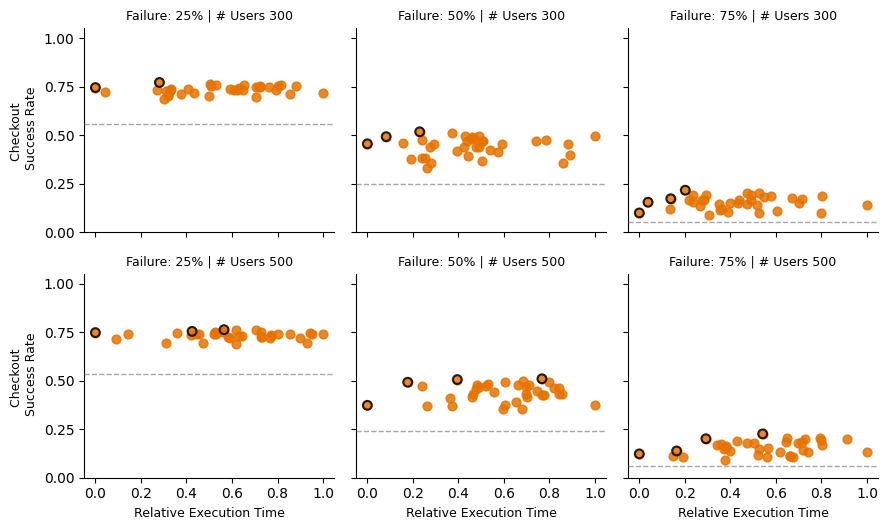


                  ploting 36 points for retry_frontend
                  workload 300 and
                  fault 25
                

                  ploting 35 points for retry_frontend
                  workload 300 and
                  fault 50
                

                  ploting 36 points for retry_frontend
                  workload 300 and
                  fault 75
                

                  ploting 36 points for retry_frontend
                  workload 500 and
                  fault 25
                

                  ploting 36 points for retry_frontend
                  workload 500 and
                  fault 50
                

                  ploting 36 points for retry_frontend
                  workload 500 and
                  fault 75
                


/tmp/ipython-input-3078822110.py:161: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


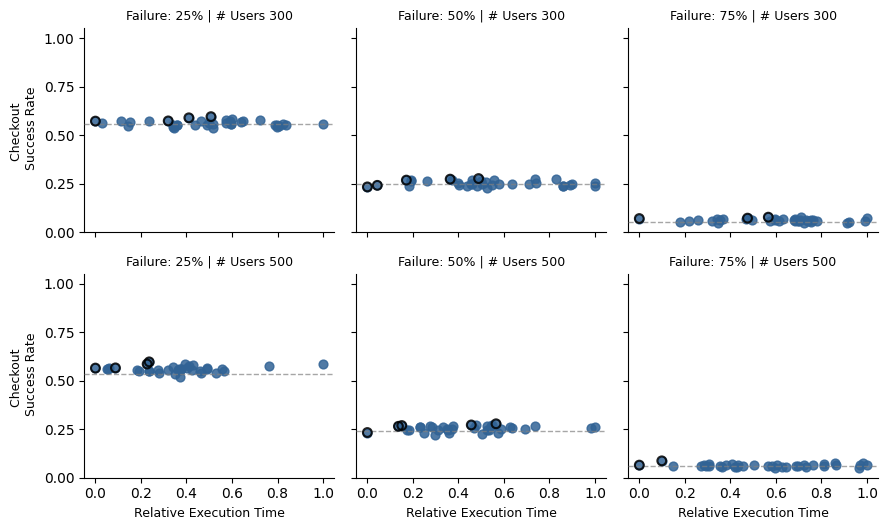


                  ploting 1259 points for retry_all
                  workload 300 and
                  fault 25
                

                  ploting 1257 points for retry_all
                  workload 300 and
                  fault 50
                

                  ploting 1256 points for retry_all
                  workload 300 and
                  fault 75
                

                  ploting 1259 points for retry_all
                  workload 500 and
                  fault 25
                

                  ploting 1244 points for retry_all
                  workload 500 and
                  fault 50
                

                  ploting 1260 points for retry_all
                  workload 500 and
                  fault 75
                


/tmp/ipython-input-3078822110.py:161: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


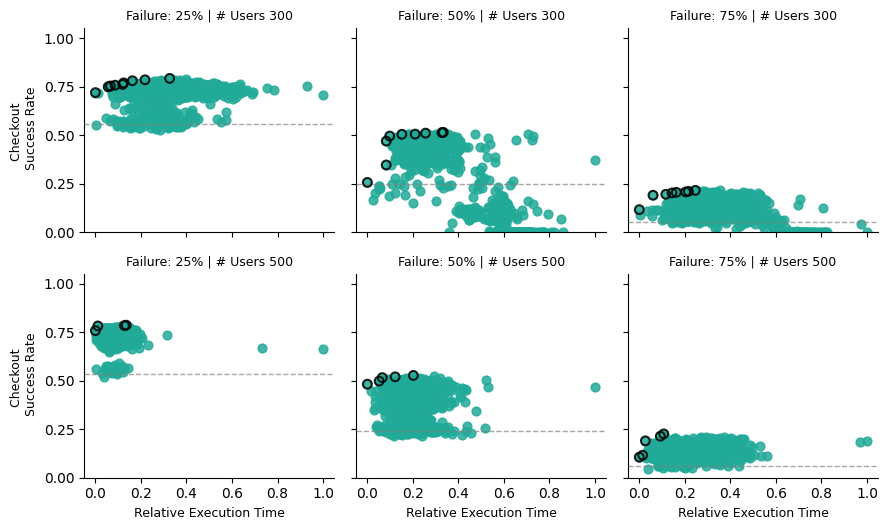

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def is_pareto_efficient(costs, return_mask=True):
    """
    Encontra os pontos que formam a fronteira de Pareto.
    Minimiza todas as dimensões de 'costs'. Para maximizar alguma métrica,
    passe o sinal invertido (ex.: -y) naquela coluna.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for idx, c in enumerate(costs):
        if is_efficient[idx]:
            # Mantém pontos que não são estritamente piores que c
            is_efficient[is_efficient] = (
                np.any(costs[is_efficient] < c, axis=1)
                | np.all(costs[is_efficient] == c, axis=1)
            )
            is_efficient[idx] = True
    return is_efficient if return_mask else np.where(is_efficient)[0]

def plot_retry_vs_baseline(
    params_df: pd.DataFrame,
    params_baseline_df: pd.DataFrame,
    x_column: str = "normalized_iteration_duration_p(95)",
    y_column: str = "checkout_success_rate",
    x_label: str = "Relative Execution Time",
    y_label: str = "Checkout \n Success Rate",
    y_min: float = 0.15,
    y_max: float = 1.05,
    x_min: float = -0.05,
    x_max: float = 1.05,
    color: str = "",
    groupname: str = "",
):
    # --- conversões de tipos para segurança ---
    for col in [x_column, y_column, "fault_percentage", "workload_users"]:
        if col in params_df.columns:
            params_df[col] = pd.to_numeric(params_df[col], errors="coerce")
        if col in params_baseline_df.columns:
            params_baseline_df[col] = pd.to_numeric(params_baseline_df[col], errors="coerce")

    # níveis (ordenados) ignorando NaN
    fault_levels = sorted(pd.Series(params_df["fault_percentage"]).dropna().unique())
    workloads    = [300, 500] #sorted(pd.Series(params_df["workload_users"]).dropna().unique())

    if len(fault_levels) == 0 or len(workloads) == 0:
        raise ValueError("params_df precisa conter ao menos um 'fault_percentage' e um 'workload_users' válidos.")

    nrows, ncols = len(workloads), len(fault_levels)

    # figura com tamanho proporcional
    fig_w = max(3.0 * ncols, 3.0)
    fig_h = max(2.7 * nrows, 2.7)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(fig_w, fig_h),
        sharex=True, sharey=True,
        constrained_layout=True
    )

    # garante que axes seja SEMPRE 2D
    axes = np.atleast_2d(axes)

    for i, workload in enumerate(workloads):
        for j, fault in enumerate(fault_levels):
            ax = axes[i, j]

            # Plot each scenario group
            subset = params_df[
                (params_df["fault_percentage"] == fault) &
                (params_df["workload_users"] == workload)
            ].copy()

            # se não houver dados, apenas configura o painel e segue
            if subset.empty: # Only configure if no data for any group
                ax.set_title(f"Failure: {fault}% | # Users {workload}", fontsize=9)
                ax.set_xlim(x_min, x_max)
                ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
                ax.set_ylim(y_min, y_max)
                ax.set_yticks([0.25, 0.5, 0.75, 1])
                ax.grid(False)
                for spine in ['top', 'right']:
                    ax.spines[spine].set_visible(False)
                if i == nrows - 1:
                    ax.set_xlabel(x_label, fontsize=9)
                if j == 0:
                    ax.set_ylabel(y_label, fontsize=9)
                continue


            # calcula Pareto (min x, max y -> usa -y)
            if not subset.empty:
                costs = np.column_stack([subset[x_column].to_numpy(), -subset[y_column].to_numpy()])
                pareto_mask = is_pareto_efficient(costs)
                subset["is_pareto"] = pareto_mask

                # destaca fronteira de Pareto (contorno)
                pareto_points = subset[subset["is_pareto"]]
                if not pareto_points.empty:
                    ax.scatter(
                        pareto_points[x_column],
                        pareto_points[y_column],
                        s=40,
                        alpha=0.85,
                        edgecolors='black',
                        linewidths=1.5,
                        facecolors='none',
                        zorder=5
                    )

                # points for the current scenario group
                print(f"""
                  ploting {subset['scenario'].size} points for {subset['scenario_group'].iloc[0]}
                  workload {workload} and
                  fault {fault}
                """)
                ax.scatter(subset[x_column], subset[y_column], alpha=0.85, s=40, color=color)

            # baseline as a horizontal line (use mean if there are multiple)
            base_y = params_baseline_df.loc[
                (params_baseline_df["fault_percentage"] == fault) &
                (params_baseline_df["workload_users"] == workload), y_column
            ]
            base_y = pd.to_numeric(base_y, errors="coerce").dropna()
            if not base_y.empty:
                ax.axhline(
                    y=base_y.mean(),
                    color="gray", linestyle="--", alpha=0.7, linewidth=1, zorder=4
                )

            # configs visuais
            ax.set_title(f"Failure: {fault}% | # Users {workload}", fontsize=9)
            # standard limits
            ax.set_xlim(x_min, x_max)
            ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
            ax.set_ylim(y_min, y_max)
            ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
            ax.grid(False)
            for spine in ['top', 'right']:
                ax.spines[spine].set_visible(False)

            # Axis labels only on border panels
            if i == nrows - 1:
                ax.set_xlabel(x_label, fontsize=9)
            if j == 0:
                ax.set_ylabel(y_label, fontsize=9)

            # (optional) if there's a single point, zoom in
            if not subset.empty and len(subset) == 1:
                xv = subset[x_column].iloc[0]
                yv = subset[y_column].iloc[0]
                ax.set_xlim(xv - 0.05, xv + 0.05)
                ax.set_ylim(yv - 0.05, yv + 0.05)

    # Add a single legend for all subplots
    handles, labels = axes[0, 0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1,1))

    plt.tight_layout()
    if groupname:
      plt.savefig(f"pareto-{groupname}.pdf", bbox_inches='tight')

    plt.show()



# --

x_column = "normalized_iteration_duration_p(95)"  # ou "normalized_checkout_http_req_duration"
x_label = "Relative Execution Time"
y_column = "checkout_success_rate"                # ou "normalized_iteration_duration_p(95)" etc.
y_label  = "Checkout \n Success Rate"

colors = ["#E67300", "#316395", "#22aa99"]
groups = ["retry_checkout", "retry_frontend", "retry_all"]

color_group = {
    "retry_checkout": "#E67300",
    "retry_frontend": "#316395",
    "retry_all": "#22aa99"
}

for group, color in zip(groups, colors):
  filtered_retry_df = retry_df[retry_df['scenario_group'] == group].copy()
  plot_retry_vs_baseline(filtered_retry_df, baseline_df, x_column, y_column, x_label, y_label, color=color, groupname=group)

In [ ]:
pareto_by_group = pd.DataFrame(columns=retry_df.columns)

# níveis (ordenados) ignorando NaN
fault_levels = sorted(pd.Series(retry_df["fault_percentage"]).dropna().unique())
workloads    = [300, 500] #sorted(pd.Series(retry_df["workload_users"]).dropna().unique())

if len(fault_levels) == 0 or len(workloads) == 0:
    raise ValueError("retry_df precisa conter ao menos um 'fault_percentage' e um 'workload_users' válidos.")

for i, workload in enumerate(workloads):
  for j, fault in enumerate(fault_levels):
    for group_index, group in enumerate(groups):

      # Plot each scenario group
      subset = retry_df[
          (retry_df["fault_percentage"] == fault) &
          (retry_df["workload_users"] == workload) &
          (retry_df["scenario_group"] == group)
      ].copy()

      # calcula Pareto (min x, max y -> usa -y)
      if not subset.empty:
          costs = np.column_stack([subset[x_column].to_numpy(), -subset[y_column].to_numpy()])
          pareto_mask = is_pareto_efficient(costs)
          subset["is_pareto"] = pareto_mask

          pareto_by_group = pd.concat([pareto_by_group, subset[subset["is_pareto"]]])


pareto_by_group.to_csv(DATASET_DIR / 'pareto.csv', index=False)

/tmp/ipython-input-1148704740.py:133: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


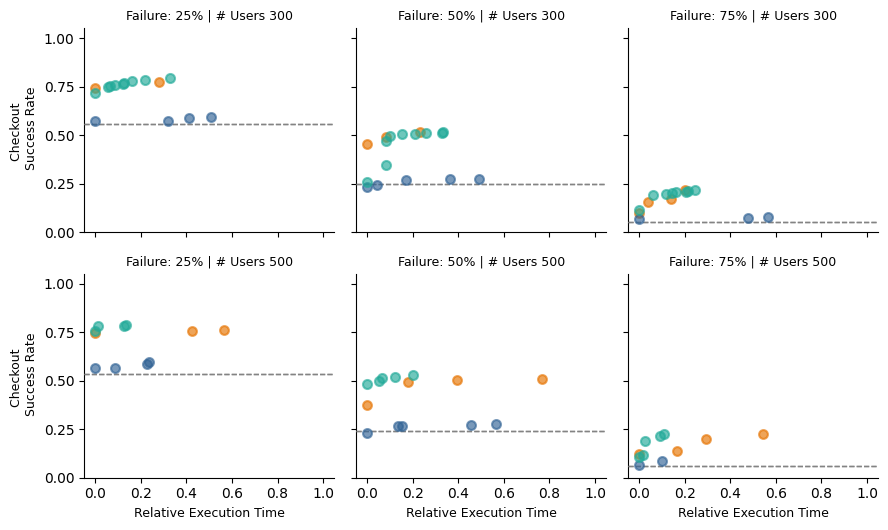

In [ ]:
def plot_pareto(
    retry_df: pd.DataFrame,
    baseline_df: pd.DataFrame,
    x_column: str = "normalized_iteration_duration_p(95)",
    y_column: str = "checkout_success_rate",
    x_label: str = "Relative Execution Time",
    y_label: str = "Checkout \n Success Rate",
    y_min: float = 0.15,
    y_max: float = 1.05,
    x_min: float = -0.05,
    x_max: float = 1.05,
):
    # --- conversões de tipos para segurança ---
    for col in [x_column, y_column, "fault_percentage", "workload_users"]:
        if col in retry_df.columns:
            retry_df[col] = pd.to_numeric(retry_df[col], errors="coerce")
        if col in baseline_df.columns:
            baseline_df[col] = pd.to_numeric(baseline_df[col], errors="coerce")

    # níveis (ordenados) ignorando NaN
    fault_levels = sorted(pd.Series(retry_df["fault_percentage"]).dropna().unique())
    workloads    = [300, 500] #sorted(pd.Series(retry_df["workload_users"]).dropna().unique())

    if len(fault_levels) == 0 or len(workloads) == 0:
        raise ValueError("retry_df precisa conter ao menos um 'fault_percentage' e um 'workload_users' válidos.")

    nrows, ncols = len(workloads), len(fault_levels)

    # figura com tamanho proporcional
    fig_w = max(3.0 * ncols, 3.0)
    fig_h = max(2.7 * nrows, 2.7)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(fig_w, fig_h),
        sharex=True, sharey=True,
        constrained_layout=True
    )

    # garante que axes seja SEMPRE 2D
    axes = np.atleast_2d(axes)

    for i, workload in enumerate(workloads):
        for j, fault in enumerate(fault_levels):
            ax = axes[i, j]

            for group_index, group in enumerate(groups):

              # Plot each scenario group
              subset = retry_df[
                  (retry_df["fault_percentage"] == fault) &
                  (retry_df["workload_users"] == workload) &
                  (retry_df["scenario_group"] == group)
              ].copy()

              # se não houver dados, apenas configura o painel e segue
              if subset.empty: # Only configure if no data for any group
                  ax.set_title(f"Failure: {fault}% | # Users {workload}", fontsize=9)
                  ax.set_xlim(x_min, x_max)
                  ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
                  ax.set_ylim(y_min, y_max)
                  ax.set_yticks([0.25, 0.5, 0.75, 1])
                  ax.grid(False)
                  for spine in ['top', 'right']:
                      ax.spines[spine].set_visible(False)
                  if i == nrows - 1:
                      ax.set_xlabel(x_label, fontsize=9)
                  if j == 0:
                      ax.set_ylabel(y_label, fontsize=9)
                  continue


              # calcula Pareto (min x, max y -> usa -y)
              if not subset.empty:
                  costs = np.column_stack([subset[x_column].to_numpy(), -subset[y_column].to_numpy()])
                  pareto_mask = is_pareto_efficient(costs)
                  subset["is_pareto"] = pareto_mask

                  # destaca fronteira de Pareto (contorno)
                  pareto_points = subset[subset["is_pareto"]]
                  if not pareto_points.empty:

                      ax.scatter(
                          pareto_points[x_column],
                          pareto_points[y_column],
                          s=40 + group_index,
                          alpha=0.65,
                          color=color_group[group],
                          linewidths=1.5,
                          zorder=5+group_index
                      )

              # baseline as a horizontal line (use mean if there are multiple)
              base_y = baseline_df.loc[
                  (baseline_df["fault_percentage"] == fault) &
                  (baseline_df["workload_users"] == workload), y_column
              ]
              base_y = pd.to_numeric(base_y, errors="coerce").dropna()
              if not base_y.empty:
                  ax.axhline(
                      y=base_y.mean(),
                      color="gray", linestyle="--", alpha=0.7, linewidth=1, zorder=4
                  )

              # configs visuais
              ax.set_title(f"Failure: {fault}% | # Users {workload}", fontsize=9)
              # standard limits
              ax.set_xlim(x_min, x_max)
              ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
              ax.set_ylim(y_min, y_max)
              ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
              ax.grid(False)
              for spine in ['top', 'right']:
                  ax.spines[spine].set_visible(False)

              # Axis labels only on border panels
              if i == nrows - 1:
                  ax.set_xlabel(x_label, fontsize=9)
              if j == 0:
                  ax.set_ylabel(y_label, fontsize=9)

              # (optional) if there's a single point, zoom in
              if not subset.empty and len(subset) == 1:
                  xv = subset[x_column].iloc[0]
                  yv = subset[y_column].iloc[0]
                  ax.set_xlim(xv - 0.05, xv + 0.05)
                  ax.set_ylim(yv - 0.05, yv + 0.05)

    # Add a single legend for all subplots
    handles, labels = axes[0, 0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1,1))

    plt.tight_layout()
    plt.savefig(f"pareto.pdf", bbox_inches='tight')
    plt.show()


x_column = "normalized_iteration_duration_p(95)"  # ou "normalized_checkout_http_req_duration"
x_label = "Relative Execution Time"
y_column = "checkout_success_rate"                # ou "normalized_iteration_duration_p(95)" etc.
y_label  = "Checkout \n Success Rate"

colors = ["#E67300", "#316395", "#22aa99"]
groups = ["retry_checkout", "retry_frontend", "retry_all"]

plot_pareto(retry_df, baseline_df, x_column, y_column, x_label, y_label)

/tmp/ipython-input-3097750387.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


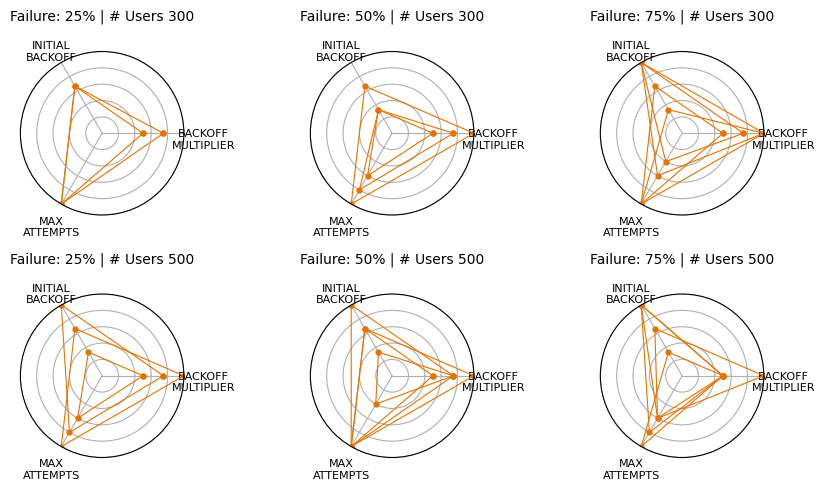

/tmp/ipython-input-3097750387.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


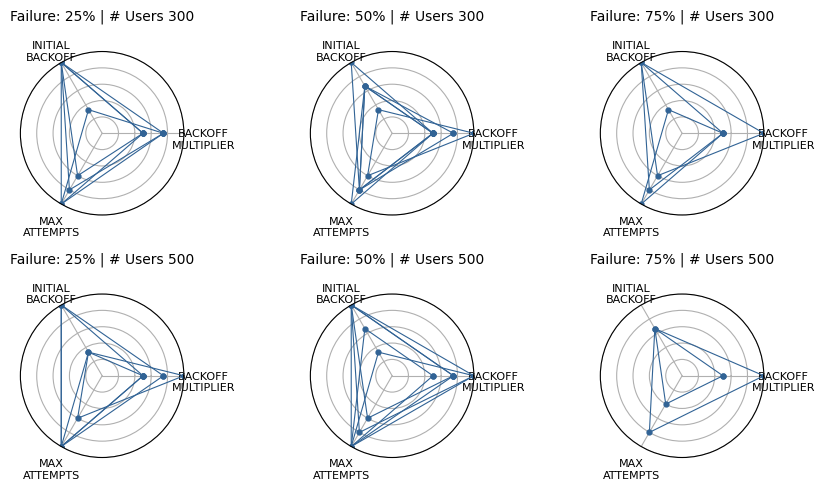

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_pareto_grpc_radar(
    retry_df: pd.DataFrame,
    group: str,
    color: str,
    x_column: str = "normalized_iteration_duration_p(95)",
    y_column: str = "checkout_success_rate",
):
    """
    Gera gráficos de radar dos parâmetros GRPC para os pontos de Pareto
    em diferentes cargas e percentuais de falha.
    """

    fault_levels = sorted(pd.Series(retry_df["fault_percentage"]).dropna().unique())
    workloads    = sorted(pd.Series(retry_df["workload_users"]).dropna().unique())

    if len(fault_levels) == 0 or len(workloads) == 0:
        raise ValueError("retry_df precisa conter ao menos um 'fault_percentage' e um 'workload_users' válidos.")

    nrows, ncols = len(workloads), len(fault_levels)

    fig_w = max(3 * ncols, 3)
    fig_h = max(2.5 * nrows, 2.5)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(fig_w, fig_h),
        subplot_kw=dict(polar=True),
        constrained_layout=True
    )
    axes = np.atleast_2d(axes)

    params_column_map = {
        "retry_checkout": "rt_cp_",
        "retry_frontend": "rt_fc_"
    }

    grpc_params_cols = [col for col in retry_df.columns if params_column_map[group] in col]
    to_drop = f'{params_column_map[group]}GRPC_MAX_BACKOFF'
    if to_drop in grpc_params_cols:
        grpc_params_cols.remove(to_drop)
    if not grpc_params_cols:
        raise ValueError("DataFrame não contém colunas de parâmetros GRPC.")

    # Normalização global
    grpc_params_only = retry_df[grpc_params_cols].copy()
    max_vals = grpc_params_only.max()
    max_vals[max_vals == 0] = 1
    grpc_params_normalized_all = grpc_params_only / max_vals

    # Rótulos dos eixos do radar
    radar_labels = [col.replace('rt_fc_', '').replace('rt_cp_', '').replace('GRPC', '').replace('_', '\n')
                    for col in grpc_params_cols]

    # ângulos fixos (fora do laço) para evitar depender do subset
    angles = np.linspace(0, 2*np.pi, len(grpc_params_cols), endpoint=False)
    angles_closed = np.concatenate((angles, [angles[0]]))

    for i, workload in enumerate(workloads):
        for j, fault in enumerate(fault_levels):
            ax = axes[i, j]

            subset = retry_df[
                (retry_df["fault_percentage"] == fault) &
                (retry_df["workload_users"] == workload) &
                (retry_df["scenario_group"] == group)
            ].copy()

            # pontos de Pareto
            pareto_subset = pd.DataFrame()
            if not subset.empty:
                costs = np.column_stack([subset[x_column].to_numpy(), -subset[y_column].to_numpy()])
                pareto_mask = is_pareto_efficient(costs)
                pareto_subset = subset[pareto_mask].copy()

            if not pareto_subset.empty:
                pareto_grpc_normalized = grpc_params_normalized_all.loc[pareto_subset.index]

                # PLOTS em preto (linhas e pontos)
                for _, row in pareto_grpc_normalized.iterrows():

                    values = row.to_numpy()
                    values = np.concatenate((values, [values[0]]))
                    ax.plot(
                        angles_closed, values,
                        linestyle='-',
                        linewidth=0.8,
                        marker='o',
                        markersize=3.5,
                        color=color,
                        markerfacecolor=color,
                        markeredgecolor=color,
                    )

            # Configuração do radar
            ax.set_thetagrids(angles * 180/np.pi, radar_labels, fontsize=8)
            ax.set_title(f"Failure: {fault}% | # Users {workload}", fontsize=10, va='bottom', pad=20)
            ax.grid(True)
            ax.set_ylim(0, 1)

            # (2) remover rótulos dos arcos internos (ticks radiais)
            ax.set_yticklabels([])            # remove labels
            # opcional: força alguns níveis de grade sem labels
            ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])

    # plt.suptitle("GRPC Parameters of Pareto Efficient Configurations", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f"radar-{group}.pdf", bbox_inches='tight')
    plt.show()


for group, color in zip(groups, colors):
  if group == "retry_all":
    continue
  plot_pareto_grpc_radar(retry_df, group, color)

/tmp/ipython-input-3233357681.py:141: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


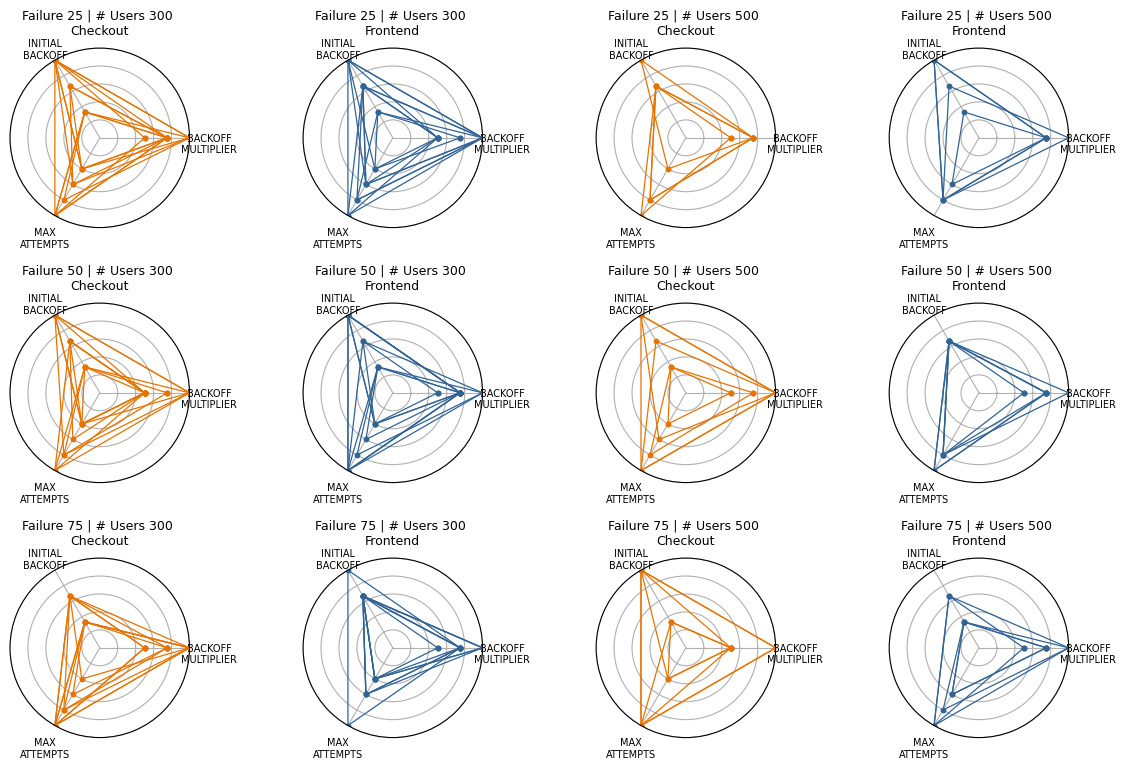

In [ ]:
def _normalize_prefix_block(df: pd.DataFrame, prefix: str) -> tuple[list, pd.DataFrame]:
    """Seleciona e normaliza (0..1) globalmente as colunas de parâmetros que começam com o prefixo."""
    cols = [c for c in df.columns if c.startswith(prefix)]
    drop_col = f"{prefix}GRPC_MAX_BACKOFF"
    if drop_col in cols:
        cols.remove(drop_col)
    if not cols:
        raise ValueError(f"DataFrame não contém colunas de parâmetros com prefixo '{prefix}'.")
    block = df[cols].copy()
    max_vals = block.max()
    max_vals[max_vals == 0] = 1
    norm = block / max_vals
    return cols, norm

def _labels_from_cols(cols: list[str]) -> list[str]:
    return [c.replace('rt_fc_', '').replace('rt_cp_', '').replace('GRPC', '').replace('_', '\n') for c in cols]


def plot_pareto_grpc_radar_retry_all(
    retry_df: pd.DataFrame,
    x_column: str = "normalized_iteration_duration_p(95)",
    y_column: str = "checkout_success_rate",
    checkout_color: str = "#E67300",
    frontend_color: str = "#316395",
):
    # Conversões defensivas
    # for col in [x_column, y_column, "fault_percentage", "workload_users", "scenario_group"]:
    #     if col in retry_df.columns:
    #         retry_df[col] = pd.to_numeric(retry_df[col], errors="coerce")

    fault_levels = sorted(pd.Series(retry_df["fault_percentage"]).dropna().unique())
    workloads    = sorted(pd.Series(retry_df["workload_users"]).dropna().unique())
    if len(fault_levels) == 0 or len(workloads) == 0:
        raise ValueError("retry_df precisa conter ao menos um 'fault_percentage' e um 'workload_users' válidos.")

    # Filtra o retry_df para conter apenas o grupo "retry_all"
    filtered_retry_df_for_all = retry_df[retry_df["scenario_group"] == "retry_all"].copy()

    # Normalizações separadas por prefixo (agora usando o DataFrame já filtrado)
    cp_cols, cp_norm_all = _normalize_prefix_block(filtered_retry_df_for_all, "rt_cp_")
    fc_cols, fc_norm_all = _normalize_prefix_block(filtered_retry_df_for_all, "rt_fc_")

    # Ângulos e rótulos por bloco
    cp_angles = np.linspace(0, 2*np.pi, len(cp_cols), endpoint=False)
    cp_angles_closed = np.concatenate((cp_angles, [cp_angles[0]]))
    fc_angles = np.linspace(0, 2*np.pi, len(fc_cols), endpoint=False)
    fc_angles_closed = np.concatenate((fc_angles, [fc_angles[0]]))
    cp_labels = _labels_from_cols(cp_cols)
    fc_labels = _labels_from_cols(fc_cols)

    # >>> NOVO LAYOUT: uma linha por falha; em cada linha, 2*len(workloads) colunas (par CP/FC por workload)
    nrows = len(fault_levels)
    ncols = len(workloads) * 2

    fig_w = max(3 * ncols, 8)
    fig_h = max(2.6 * nrows, 3.2)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(fig_w, fig_h),
        subplot_kw=dict(polar=True),
        constrained_layout=True
    )
    axes = np.atleast_2d(axes)

    for r, fault in enumerate(fault_levels):
        # Título da LINHA (falha) – colocado uma única vez por grupo/linha
        # (usamos as posições do primeiro e do último eixo da linha para centralizar)
        # left_x  = axes[r, 0].get_position().x0
        # right_x = axes[r, -1].get_position().x1
        # row_top = max(ax.get_position().y1 for ax in axes[r, :])
        # fig.text(
        #     0.5 * (left_x + right_x),
        #     row_top + 0.03,  # espaço acima da fileira
        #     f"Failure: {fault}%",
        #     ha="center", va="bottom", fontsize=11, fontweight="bold"
        # )

        for c, workload in enumerate(workloads):
            ax_cp = axes[r, c*2]
            ax_fc = axes[r, c*2 + 1]

            subset = filtered_retry_df_for_all[
                (filtered_retry_df_for_all["fault_percentage"] == fault) &
                (filtered_retry_df_for_all["workload_users"] == workload)
            ].copy()

            pareto_subset = pd.DataFrame()
            if not subset.empty:
                costs = np.column_stack([subset[x_column].to_numpy(), -subset[y_column].to_numpy()])
                pareto_mask = is_pareto_efficient(costs)
                pareto_subset = subset[pareto_mask].copy()

            # ----- TÍTULO DO PAR (Users) uma única vez sobre o par -----
            # pair_left  = ax_cp.get_position().x0
            # pair_right = ax_fc.get_position().x1
            # pair_top   = max(ax_cp.get_position().y1, ax_fc.get_position().y1)
            # fig.text(
            #     0.5 * (pair_left + pair_right),
            #     pair_top + 0.015,
            #     f"Users: {workload}",
            #     ha="center", va="bottom", fontsize=9
            # )

            # ----- Checkout (rt_cp_) -----
            ax = ax_cp
            ax.set_title(f"Failure {fault} | # Users {workload} \nCheckout", fontsize=9, pad=10)
            ax.set_thetagrids(cp_angles * 180/np.pi, cp_labels, fontsize=7)
            ax.set_ylim(0, 1)
            ax.set_yticklabels([])
            ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
            ax.grid(True)
            if not pareto_subset.empty:
                cp_norm = cp_norm_all.loc[pareto_subset.index]
                for _, row in cp_norm.iterrows():
                    vals = np.concatenate((row.to_numpy(), [row.to_numpy()[0]]))
                    ax.plot(
                        cp_angles_closed, vals,
                        linestyle='-', linewidth=0.9, marker='o', markersize=3.2,
                        color=checkout_color, markerfacecolor=checkout_color, markeredgecolor=checkout_color
                    )

            # ----- Frontend (rt_fc_) -----
            ax = ax_fc
            ax.set_title(f"Failure {fault} | # Users {workload} \nFrontend", fontsize=9, pad=10)
            ax.set_thetagrids(fc_angles * 180/np.pi, fc_labels, fontsize=7)
            ax.set_ylim(0, 1)
            ax.set_yticklabels([])
            ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
            ax.grid(True)
            if not pareto_subset.empty:
                fc_norm = fc_norm_all.loc[pareto_subset.index]
                for _, row in fc_norm.iterrows():
                    vals = np.concatenate((row.to_numpy(), [row.to_numpy()[0]]))
                    ax.plot(
                        fc_angles_closed, vals,
                        linestyle='-', linewidth=0.9, marker='o', markersize=3.2,
                        color=frontend_color, markerfacecolor=frontend_color, markeredgecolor=frontend_color
                    )

    plt.tight_layout()
    plt.savefig("radar-retry_all.pdf", bbox_inches='tight')
    plt.show()

plot_pareto_grpc_radar_retry_all(retry_df)

In [ ]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Use only retry_checkout scenarios (connector under study)
df = df[df["scenario_group"] == "retry_checkout"]

# %%

# Configuration
params = ["INITIAL_BACKOFF", "BACKOFF_MULTIPLIER", "MAX_ATTEMPTS"]

# Scaling Logic
scaling_config = {
    "INITIAL_BACKOFF": {"center": -0.5, "max": 1.5, "unit": "", "fmt": "{:.1f}"},
    "BACKOFF_MULTIPLIER": {"center": 0.0, "max": 2.0, "unit": "", "fmt": "{:.1f}"},
    "MAX_ATTEMPTS": {"center": 1.0, "max": 5.0, "unit": "", "fmt": "{:.0f}"}
}

pretty_labels = {
    "INITIAL_BACKOFF": "Initial\nBackoff",
    "BACKOFF_MULTIPLIER": "Backoff\nMultiplier",
    "MAX_ATTEMPTS": "Max\nAttempts"
}

def make_radar(ax, values_df, params, title):
    # --- Setup Geometry ---
    N = len(params)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1] # Close the loop

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # --- Setup Grid ---
    # Disable default labels to use manual placement
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    # Exactly 4 circles at 25%, 50%, 75%, 100% radius
    grid_ticks = [0.25, 0.5, 0.75, 1.0]
    ax.set_yticks(grid_ticks)
    ax.set_yticklabels([]) # Hide default radial labels
    ax.set_rlabel_position(0)
    ax.set_ylim(0, 1.0)

    # --- Plot Data ---
    for i, row in values_df.iterrows():
        normalized_vals = []
        for p in params:
            cfg = scaling_config[p]
            norm = (row[p] - cfg["center"]) / (cfg["max"] - cfg["center"])
            normalized_vals.append(norm)

        vals_plot = normalized_vals + normalized_vals[:1]
        ax.plot(angles, vals_plot, linewidth=2, linestyle='solid')
        ax.fill(angles, vals_plot, alpha=0.1)

    # --- Custom Axis Value Labels (Inside the chart) ---
    for idx, angle in enumerate(angles[:-1]):
        param_name = params[idx]
        cfg = scaling_config[param_name]

        for tick in grid_ticks:
            real_val = cfg["center"] + tick * (cfg["max"] - cfg["center"])
            val_str = cfg["fmt"].format(real_val)
            label_text = f"{val_str}{cfg['unit']}"

            # Transparent background (no bbox)
            ax.text(angle, tick, label_text,
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=10, color='#444444', weight='normal')

    # --- Manual Axis Titles (Placed Further Out) ---
    label_radius = 1.10

    for idx, angle in enumerate(angles[:-1]):
        label_text = pretty_labels[params[idx]]

        if np.isclose(angle, 0):
            ha, va = 'center', 'bottom'
        elif 0 < angle < np.pi:
            ha, va = 'left', 'top'
        else:
            ha, va = 'right', 'top'

        ax.text(angle, label_radius, label_text,
                size=12, weight='normal',
                horizontalalignment=ha,
                verticalalignment=va)

    ax.set_title(title, fontsize=12, pad=50, weight='normal')

# --- Main Execution (Grid Plot) ---
# Group and sort by fault % and then users to match the desired order
groups = df.groupby(["fault_percentage", "workload_users"])
sorted_keys = sorted(groups.groups.keys())

# Define the specific order: Row 1 (300 users), Row 2 (500 users)
ordered_keys = [
    (25, 300), (50, 300), (75, 300),
    (25, 500), (50, 500), (75, 500)
]

# Create a 2x3 grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, key in enumerate(ordered_keys):
    fault, users = key
    group = groups.get_group(key)

    # Plot on the specific subplot axis (i)
    ax = axes[i]
    title = f"Failure Rate: {fault}% | Users: {users}"
    make_radar(ax, group[params], params, title)

plt.tight_layout()
# wspace=0.4 means the space between plots is 40% of the average plot width
plt.subplots_adjust(wspace=0.9, hspace=0.15)
plt.savefig("radar-retry-checkout.pdf", format="pdf", bbox_inches='tight')
plt.show()
# %%
